In [3]:
pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [kagglehub]/3 [kagglehub]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("priyankraval/nurse-stress-prediction-wearable-sensors")

print("Path to dataset files:", path)

100%|██████████| 76.2M/76.2M [00:05<00:00, 13.6MB/s]

Extracting files...


Path to dataset files: /Users/iriskwon/.cache/kagglehub/datasets/priyankraval/nurse-stress-prediction-wearable-sensors/versions/1


In [6]:
import pandas as pd
import os

os.getcwd()
path = '/Users/iriskwon/Documents/Spr26/MLMA Final Project/'

df = pd.read_csv(os.path.join(path, 'merged_data.csv'))

/var/folders/jc/r13c712s6dj2g5bnkv832wk40000gn/T/ipykernel_17327/4289001169.py:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(path, 'merged_data.csv'))


In [7]:
df.head()

,X,Y,Z,EDA,HR,TEMP,id,datetime,label
0,-13.0,-61.0,5.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.000000000,2.0
1,-20.0,-69.0,-3.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.031249920,2.0
2,-31.0,-78.0,-15.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.062500096,2.0
3,-47.0,-65.0,-38.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.093750016,2.0
4,-67.0,-57.0,-53.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.124999936,2.0


In [ ]:
len(df['id'].unique())
unique_nurses_id = df['id'].unique()
print(unique_nurses_id)

# Convert all IDs to strings to standardize them
df['id'] = df['id'].astype(str)

# Check the unique nurse IDs after standardization
unique_nurses_id = df['id'].unique()
print(f"Number of unique nurse IDs: {len(unique_nurses_id)}")
print(unique_nurses_id)

[15 '15' '5C' '6B' '6D' '7A' '7E' '83' 83 '8B' '94' 94 'BG' 'CE' 'DF' 'E4'
 'EG' 'F5']
Number of unique nurse IDs: 15
['15' '5C' '6B' '6D' '7A' '7E' '83' '8B' '94' 'BG' 'CE' 'DF' 'E4' 'EG'
 'F5']


In [19]:
# Assuming the dataset has columns 'nurse_id' and 'label'
# Group by nurse and label to count occurrences
label_distribution = df.groupby(['id', 'label']).size().reset_index(name='count')

# Pivot the data for visualization 
pivot_table = label_distribution.pivot(index='id',columns='label', values='count').fillna(0)

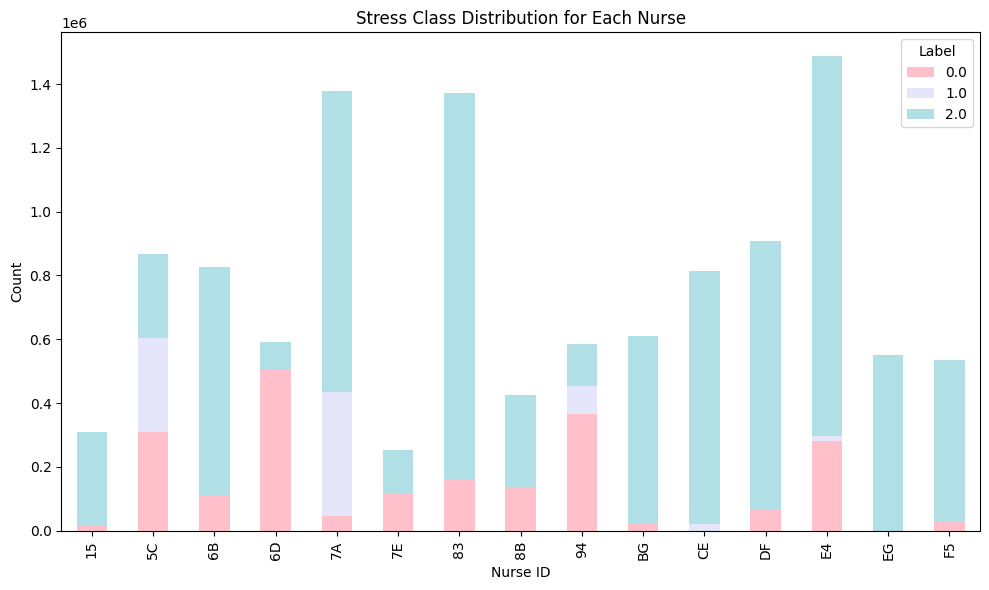

In [28]:
import matplotlib.pyplot as plt 

# Plot the distribution
pivot_table.plot(kind='bar', stacked=True, figsize=(10, 6), color = ['pink','lavender','powderblue'])

plt.title('Stress Class Distribution for Each Nurse')
plt.xlabel('Nurse ID')
plt.ylabel('Count')
plt.legend(title='Label')
plt.tight_layout()

# Show the plot
plt.show()

In [31]:
df.isna().sum()

X           0
Y           0
Z           0
EDA         0
HR          0
TEMP        0
id          0
datetime    0
label       0
dtype: int64

In [29]:
unique_nurses_id

array(['15', '5C', '6B', '6D', '7A', '7E', '83', '8B', '94', 'BG', 'CE',
       'DF', 'E4', 'EG', 'F5'], dtype=object)

In [7]:
df['label'].unique()
df['label'].value_counts()

,count
label,
2.0,8540583
0.0,2162246
1.0,806222


In [10]:
label_counts = df['label'].value_counts()
ratio = label_counts[2.0] / label_counts[0.0]
print(f"Ratio of label 2.0 to label 0.0 counts: {ratio}")

Ratio of label 2.0 to label 0.0 counts: 3.9498664814271827


In [11]:
df.groupby('id')['label'].value_counts()

id  label
15  2.0       248703
    0.0        13441
83  2.0      1147516
    0.0       163204
94  0.0       348874
    2.0        87956
    1.0        87458
15  2.0        46987
5C  0.0       309121
    1.0       295685
    2.0       261124
6B  2.0       718027
    0.0       107522
6D  0.0       503041
    2.0        88322
7A  2.0       942743
    1.0       388517
    0.0        46082
7E  2.0       136323
    0.0       117124
83  2.0        62099
8B  2.0       285520
    0.0       138243
94  2.0        44529
    0.0        17279
BG  2.0       587533
    0.0        21122
CE  2.0       794886
    1.0        19201
DF  2.0       842886
    0.0        65282
E4  2.0      1191320
    0.0       281190
    1.0        15361
EG  2.0       549124
F5  2.0       504985
    0.0        30721
Name: count, dtype: int64

In [11]:
df.groupby('label')[['HR','EDA','TEMP']].mean()

,HR,EDA,TEMP
label,,,
0.0,86.615423,2.950669,31.638143
1.0,86.452402,3.068973,31.987733
2.0,85.479283,3.682631,32.408568
